# Import des bibliothèques

In [ ]:
# Section 1 : Import des bibliothèques
import os
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Activation, Flatten, Dense
import matplotlib.pyplot as plt

# Paramètres du modèle

Dans cette section, les paramètres principaux du modèle sont définis, comme la taille des images, les chemins vers les dossiers contenant les données d’entraînement et de test, le nombre d’échantillons, le nombre d’epochs et la taille du batch. On définit également la forme de l’image d’entrée selon le format utilisé par Keras.

In [ ]:
os.chdir("/content/drive/MyDrive/Dl/TP2/v_data")
img_width, img_height = 224, 224
train_data_dir = '/content/drive/MyDrive/Dl/TP2/v_data/v_data/train'
validation_data_dir = '/content/drive/MyDrive/Dl/TP2/v_data/v_data/test'
nb_train_samples = 400
nb_validation_samples = 100
epochs = 15
batch_size = 16
num_filters = 8
filter_size = 3

# définir la forme de l'entrée selon le format utilisé par keras
if K.image_data_format() == 'channels_first':
    input_shape = (3, img_width, img_height)
else:
    input_shape = (img_width, img_height, 3)

# Transformation et préparation des données

Cette partie prépare les images avant l’entraînement du modèle. Les images sont normalisées en divisant les valeurs des pixels par 255 et plusieurs transformations sont appliquées comme le zoom ou le retournement horizontal afin d’augmenter la diversité des données et améliorer la capacité de généralisation du modèle

ImageDataGenerator charge automatiquement les images depuis les dossiers train et test. Les images sont redimensionnées et regroupées en lots (batchs) afin d’être utilisées efficacement pendant l’entraînement du réseau de neurones.

In [ ]:
train_datagen = ImageDataGenerator(
    # normalisation des pixels entre 0 et 1
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# pour les données de test on applique seulement la normalisation
test_datagen = ImageDataGenerator(rescale=1./255)

# génération des images d'entraînement depuis le dossier
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

# génération des images de validation
validation_generator = test_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


# Architecture du CNN

Cette section définit l’architecture du réseau de neurones convolutif. Elle contient une couche de convolution pour extraire les caractéristiques des images, une fonction d’activation ReLU pour introduire la non-linéarité, une couche de max pooling pour réduire la dimension des données, puis des couches fully connected pour effectuer la classification finale en deux classes.

In [ ]:
# Construction de l’architecture du réseau CNN
model = Sequential()
model.add(Conv2D(num_filters, (3,3), input_shape=input_shape))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(24))
model.add(Dense(2))
model.add(Activation('sigmoid'))

print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 222, 222, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 98568)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │     2,365,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,365,930 (9.03 MB)

 Trainable params: 2,365,930 (9.03 MB)

 Non-trainable params: 0 (0.00 B)

None


# Entrainement et évaluation

Le modèle est compilé avec une fonction de perte adaptée à la classification binaire et un optimiseur RMSprop. Ensuite, le modèle est entraîné sur les données d’apprentissage pendant plusieurs epochs tout en évaluant sa performance sur les données de validation.

In [ ]:
model.compile(
    loss='binary_crossentropy',   # fonction de perte pour classification binaire
    optimizer='rmsprop',          # algorithme d’optimisation
    metrics=['accuracy']          # métrique utilisée pour évaluer le modèle
)

# entraînement du modèle
history = model.fit(
    train_generator,
    steps_per_epoch = nb_train_samples // batch_size,
    epochs = epochs,
    validation_data = validation_generator,
    validation_steps = nb_validation_samples // batch_size
)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 140s 5s/step - accuracy: 0.4550 - loss: 11.0982 - val_accuracy: 0.5000 - val_loss: 6.9403
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 255ms/step - accuracy: 0.6600 - loss: 2.1408 - val_accuracy: 0.8542 - val_loss: 0.3486
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 263ms/step - accuracy: 0.8350 - loss: 0.4752 - val_accuracy: 0.9062 - val_loss: 0.3268
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 230ms/step - accuracy: 0.7875 - loss: 0.4900 - val_accuracy: 0.8229 - val_loss: 0.3572
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 287ms/step - accuracy: 0.8650 - loss: 0.3787 - val_accuracy: 0.8542 - val_loss: 0.4244
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 231ms/step - accuracy: 0.8400 - loss: 0.4286 - val_accuracy: 0.7917 - val_loss: 0.4669
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 298ms/step - accuracy: 0.8700 - loss: 0.3459 - val_accuracy: 0.8438 - val_loss: 0.4463
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 231ms/step - accuracy: 0.8725 - loss: 0.3058 - val_accuracy: 0.

# Visualisation des résultats

affiche les graphiques de l’accuracy et de la fonction de perte pour les données d’entraînement et de validation. Ces graphiques permettent d’analyser les performances du modèle et de vérifier si le réseau apprend correctement.

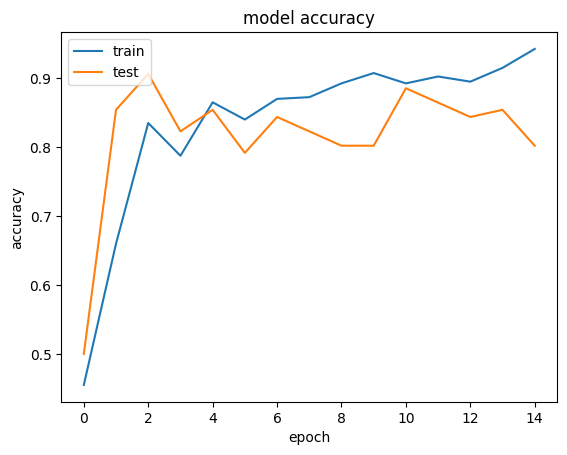

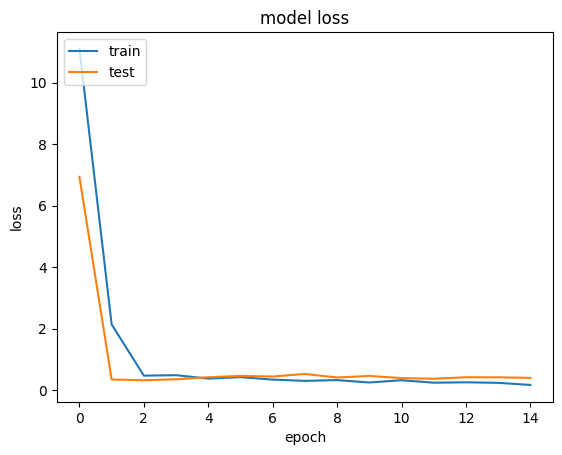

In [ ]:
# graphique de l'accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# graphique de la fonction de perte
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# Question 3

Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 222, 222, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 98568)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │     2,365,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,365,930 (9.03 MB)

 Trainable params: 2,365,930 (9.03 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.4875 - loss: 18.4576 - val_accuracy: 0.6250 - val_loss: 2.2546
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.7000 - loss: 1.5551 - val_accuracy: 0.8438 - val_loss: 0.4309
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.8375 - loss: 0.4691 - val_accuracy: 0.6562 - val_loss: 0.8609
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.9300 - loss: 0.2262 - val_accuracy: 0.8854 - val_loss: 0.3206
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.9325 - loss: 0.2417 - val_accuracy: 0.8229 - val_loss: 0.4107
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.9750 - loss: 0.1012 - val_accuracy: 0.8333 - val_loss: 0.4611
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 1.0000 - loss: 0.0164 - val_accuracy: 0.8750 - val_loss: 0.4445
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 0.

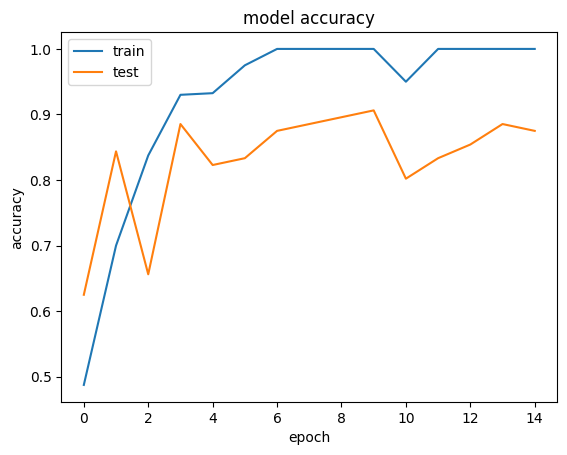

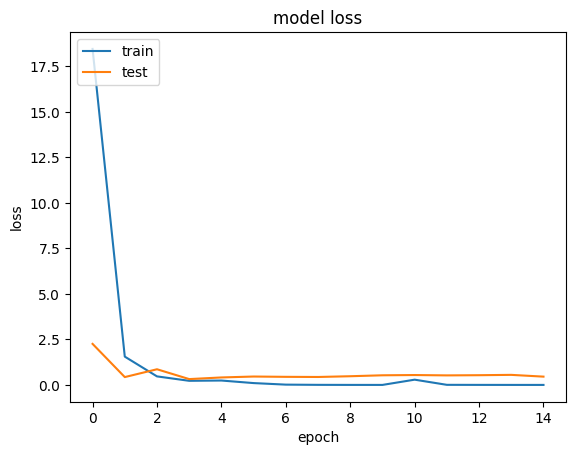

In [ ]:
train_datagen = ImageDataGenerator(
    # normalisation des pixels entre 0 et 1
    rescale=1./255,
)

# pour les données de test on applique seulement la normalisation
test_datagen = ImageDataGenerator(rescale=1./255)

# génération des images d'entraînement depuis le dossier
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

# génération des images de validation
validation_generator = test_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)
# Construction de l’architecture du réseau CNN
model = Sequential()
model.add(Conv2D(num_filters, (3,3), input_shape=input_shape))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(24))
model.add(Dense(2))
model.add(Activation('sigmoid'))

print(model.summary())
model.compile(
    loss='binary_crossentropy',   # fonction de perte pour classification binaire
    optimizer='rmsprop',          # algorithme d’optimisation
    metrics=['accuracy']          # métrique utilisée pour évaluer le modèle
)

# entraînement du modèle
history = model.fit(
    train_generator,
    steps_per_epoch = nb_train_samples // batch_size,
    epochs = epochs,
    validation_data = validation_generator,
    validation_steps = nb_validation_samples // batch_size
)
# graphique de l'accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# graphique de la fonction de perte
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

La suppression des techniques d’augmentation de données réduit la diversité des images d’entraînement. Par conséquent, le modèle a tendance à surapprendre les données d’apprentissage, ce qui entraîne une moins bonne généralisation et des performances de classification légèrement inférieures sur les données de test.

# Question 4 : Nouvelle architecture CNN

In [ ]:
# Construction d'une nouvelle architecture CNN
from tensorflow.keras.layers import Dropout

model = Sequential()

# première couche convolutionnelle
model.add(Conv2D(16, (3,3), activation='relu', input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2,2)))

# deuxième couche convolutionnelle
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# transformation en vecteur
model.add(Flatten())

# couche fully connected
model.add(Dense(64, activation='relu'))

# couche dropout pour réduire le surapprentissage
model.add(Dropout(0.5))

# couche de sortie
model.add(Dense(2, activation='sigmoid'))

print(model.summary())

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 93312)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │     5,972,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,977,250 (22.80 MB)

 Trainable params: 5,977,250 (22.80 MB)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.6550 - loss: 0.8974 - val_accuracy: 0.8750 - val_loss: 0.4319
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.8125 - loss: 0.4509 - val_accuracy: 0.8542 - val_loss: 0.3420
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.8325 - loss: 0.3634 - val_accuracy: 0.8229 - val_loss: 0.3920
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - accuracy: 0.9025 - loss: 0.2752 - val_accuracy: 0.9167 - val_loss: 0.2434
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.9375 - loss: 0.1834 - val_accuracy: 0.9062 - val_loss: 0.2787
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.9575 - loss: 0.1671 - val_accuracy: 0.8229 - val_loss: 0.4176
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.9600 - loss: 0.1432 - val_accuracy: 0.9167 - val_loss: 0.2461
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.9725 - loss: 0.0889 - val_accuracy: 0.8750 

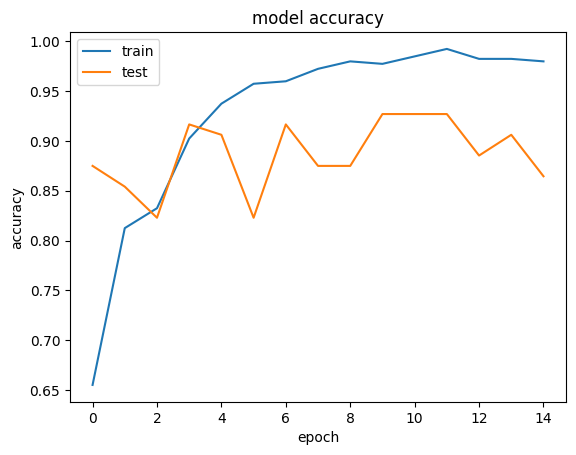

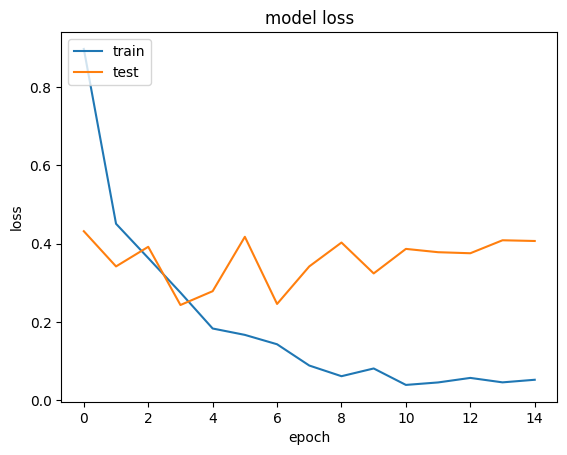

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    steps_per_epoch=nb_train_samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=nb_validation_samples // batch_size
)
# graphique de l'accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# graphique de la fonction de perte
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

La nouvelle architecture CNN offre de meilleures performances de classification que l’architecture originale. L’ajout de plusieurs couches convolutionnelles permet d’extraire des caractéristiques plus complexes des images, tandis que la couche Dropout aide à réduire le surapprentissage. Par conséquent, le modèle obtient une accuracy plus élevée et une meilleure capacité de généralisation sur les données de test

# Question 5 : Quelles sont les modifications qui doivent être apportées pour permettre la classification en fonction seulement de la fonction luminance (en niveaux de gris) ?

Pour réaliser la classification basée uniquement sur la luminance, les images doivent être converties en niveaux de gris en utilisant color_mode='grayscale' dans ImageDataGenerator, et la forme de l’entrée du réseau doit être modifiée pour utiliser un seul canal (img_width, img_height, 1) au lieu de trois canaux RGB